# Phase 4 — Baseline Drug-Response Prediction

## Objective

Establish baseline performance for cancer drug-response prediction before implementing GraphTCDR.

The models will use:

- GraphTCDR multi-omics features for 28 pancreatic cancer cell lines
- 2,048-bit Morgan fingerprints for 1,228 drugs
- PRISM log10(IC50) as the prediction target

## Baseline Models

1. MLP
2. Random Forest
3. XGBoost

## Evaluation Strategy

All models will use the same fixed **cold-drug split** created in Phase 3.

- Training: 982 drugs / 14,235 cell–drug pairs
- Testing: 246 drugs / 3,802 cell–drug pairs
- Drug overlap: 0

## Evaluation Metrics

- RMSE
- MAE
- R²
- Pearson Correlation
- Spearman Correlation

The baseline results will provide a reference for evaluating the subsequent GraphTCDR and tail-aware GraphTCDR models.

## 1. Load Required Libraries

We will use:

- NumPy and Pandas for data handling
- PyTorch for the MLP baseline
- Scikit-learn for Random Forest, preprocessing, and evaluation
- XGBoost for gradient-boosting regression

The same fixed train/test split from Phase 3 will be used throughout Phase 4.

In [2]:
# Core libraries
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# Scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Check XGBoost
import xgboost as xgb

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("XGBoost:", xgb.__version__)

print("\nLibraries loaded successfully.")

NumPy: 2.2.6
Pandas: 2.3.3
PyTorch: 2.14.0+cpu
XGBoost: 3.2.0

Libraries loaded successfully.


### 2. Load the Phase 3 Dataset

We load the processed data created in Phase 3:

- Integrated modeling table
- Fixed cold-drug training split
- Fixed cold-drug test split
- 28-cell-line multi-omics feature matrices
- 1,228-drug Morgan fingerprints

The saved cold-drug split will be used unchanged for all Phase 4 models.

In [3]:
# Project paths
project_dir = Path("..")
processed_dir = project_dir / "data" / "processed"
split_dir = processed_dir / "splits"

# Load the fixed cold-drug split
train_table = pd.read_csv(
    split_dir / "cold_drug_train.csv"
)

test_table = pd.read_csv(
    split_dir / "cold_drug_test.csv"
)

# Load multi-omics features
gene_expr = torch.load(
    processed_dir / "pancreatic28_gene_expression.pt",
    weights_only=True
)

cnv = torch.load(
    processed_dir / "pancreatic28_cnv.pt",
    weights_only=True
)

mirna = torch.load(
    processed_dir / "pancreatic28_mirna.pt",
    weights_only=True
)

methylation = torch.load(
    processed_dir / "pancreatic28_methylation.pt",
    weights_only=True
)

# Load drug fingerprints
drug_fingerprints = np.load(
    processed_dir / "drug_morgan_fingerprints_1228x2048.npy"
)

print("Train table:", train_table.shape)
print("Test table:", test_table.shape)

print("\nGene expression:", gene_expr.shape)
print("CNV:", cnv.shape)
print("miRNA:", mirna.shape)
print("Methylation:", methylation.shape)

print("\nDrug fingerprints:", drug_fingerprints.shape)

Train table: (14235, 7)
Test table: (3802, 7)

Gene expression: torch.Size([28, 20404])
CNV: torch.Size([28, 22582])
miRNA: torch.Size([28, 734])
Methylation: torch.Size([28, 20587])

Drug fingerprints: (1228, 2048)


### 3. Prepare Compact Cell-Line Multi-Omics Features

The raw GraphTCDR omics matrices contain tens of thousands of features.

For the conventional ML baselines, directly combining all raw omics features would create an extremely high-dimensional input relative to the 28 available cell lines.

Therefore, we will first learn compact representations of each omics dataset using PCA.

PCA will be fitted using the training cell lines only, where applicable, to avoid information leakage.

In [4]:
# Check cell-line coverage in the fixed cold-drug split

train_cells = set(train_table["depmap_id"])
test_cells = set(test_table["depmap_id"])

print("Unique training cell lines:", len(train_cells))
print("Unique test cell lines:", len(test_cells))
print("Cell lines in both sets:", len(train_cells.intersection(test_cells)))

print("\nTraining cell lines:")
print(sorted(train_cells))

print("\nTest cell lines:")
print(sorted(test_cells))

Unique training cell lines: 28
Unique test cell lines: 28
Cell lines in both sets: 28

Training cell lines:
['ACH-000022', 'ACH-000023', 'ACH-000042', 'ACH-000060', 'ACH-000107', 'ACH-000118', 'ACH-000138', 'ACH-000139', 'ACH-000155', 'ACH-000164', 'ACH-000178', 'ACH-000222', 'ACH-000235', 'ACH-000243', 'ACH-000266', 'ACH-000270', 'ACH-000307', 'ACH-000320', 'ACH-000332', 'ACH-000347', 'ACH-000417', 'ACH-000468', 'ACH-000502', 'ACH-000517', 'ACH-000535', 'ACH-000599', 'ACH-000652', 'ACH-000685']

Test cell lines:
['ACH-000022', 'ACH-000023', 'ACH-000042', 'ACH-000060', 'ACH-000107', 'ACH-000118', 'ACH-000138', 'ACH-000139', 'ACH-000155', 'ACH-000164', 'ACH-000178', 'ACH-000222', 'ACH-000235', 'ACH-000243', 'ACH-000266', 'ACH-000270', 'ACH-000307', 'ACH-000320', 'ACH-000332', 'ACH-000347', 'ACH-000417', 'ACH-000468', 'ACH-000502', 'ACH-000517', 'ACH-000535', 'ACH-000599', 'ACH-000652', 'ACH-000685']


### 4. Build a Cell-Line Feature Representation

For the baseline models, each cell–drug pair needs a single numerical feature vector.

The GraphTCDR multi-omics matrices are high-dimensional, so we will reduce each omics representation to a compact number of components using PCA.

The same cell-line representation will be used for every drug tested on that cell line.

The drug representation will remain the 2,048-bit Morgan fingerprint.

In [5]:
# Check the numerical range of each processed omics matrix

omics_data = {
    "Gene Expression": gene_expr,
    "CNV": cnv,
    "miRNA": mirna,
    "Methylation": methylation
}

for name, data in omics_data.items():
    data_np = data.numpy()

    print(f"{name}:")
    print(f"  Min:  {data_np.min():.6f}")
    print(f"  Max:  {data_np.max():.6f}")
    print(f"  Mean: {data_np.mean():.6f}")
    print()

Gene Expression:
  Min:  0.000000
  Max:  1.000000
  Mean: 0.376386

CNV:
  Min:  0.000000
  Max:  1.000000
  Mean: 0.550306

miRNA:
  Min:  0.000000
  Max:  1.000000
  Mean: 0.296399

Methylation:
  Min:  0.000000
  Max:  1.000000
  Mean: 0.292466



In [6]:
from sklearn.decomposition import PCA

# Convert PyTorch tensors to NumPy arrays
gene_expr_np = gene_expr.numpy()
cnv_np = cnv.numpy()
mirna_np = mirna.numpy()
methylation_np = methylation.numpy()

# Number of PCA components
N_COMPONENTS = 10

# Fit PCA separately for each omics type
pca_gene = PCA(n_components=N_COMPONENTS, random_state=42)
pca_cnv = PCA(n_components=N_COMPONENTS, random_state=42)
pca_mirna = PCA(n_components=N_COMPONENTS, random_state=42)
pca_methylation = PCA(n_components=N_COMPONENTS, random_state=42)

gene_expr_pca = pca_gene.fit_transform(gene_expr_np)
cnv_pca = pca_cnv.fit_transform(cnv_np)
mirna_pca = pca_mirna.fit_transform(mirna_np)
methylation_pca = pca_methylation.fit_transform(methylation_np)

print("Gene expression PCA:", gene_expr_pca.shape)
print("CNV PCA:", cnv_pca.shape)
print("miRNA PCA:", mirna_pca.shape)
print("Methylation PCA:", methylation_pca.shape)

Gene expression PCA: (28, 10)
CNV PCA: (28, 10)
miRNA PCA: (28, 10)
Methylation PCA: (28, 10)


### 6. Check PCA Variance Retention

We evaluate how much of the original variation is retained by the 10 PCA components for each omics dataset.

This provides a quantitative justification for the dimensionality-reduction choice.

In [7]:
# Calculate cumulative explained variance
pca_variance = pd.DataFrame({
    "Omics": [
        "Gene Expression",
        "CNV",
        "miRNA",
        "Methylation"
    ],
    "Variance_10PC": [
        pca_gene.explained_variance_ratio_.sum(),
        pca_cnv.explained_variance_ratio_.sum(),
        pca_mirna.explained_variance_ratio_.sum(),
        pca_methylation.explained_variance_ratio_.sum()
    ]
})

pca_variance["Variance_10PC_%"] = (
    pca_variance["Variance_10PC"] * 100
)

display(pca_variance)

,Omics,Variance_10PC,Variance_10PC_%
0,Gene Expression,0.591935,59.193485
1,CNV,0.636995,63.699543
2,miRNA,0.706049,70.604881
3,Methylation,0.613282,61.328209


In [8]:
# Combine the four PCA-reduced omics representations
omics_features = np.concatenate(
    [
        gene_expr_pca,
        cnv_pca,
        mirna_pca,
        methylation_pca
    ],
    axis=1
)

print("Combined multi-omics feature matrix:", omics_features.shape)
print("Features per cell line:", omics_features.shape[1])

Combined multi-omics feature matrix: (28, 40)
Features per cell line: 40


### 8. Build Model Input Features

For each cell–drug pair, we combine:

**Cell-line features**
- 40 PCA-based multi-omics features

**Drug features**
- 2,048-bit Morgan fingerprint

Therefore, each cell–drug pair will initially have:

**40 + 2,048 = 2,088 input features**

The response variable remains:

**log10(IC50)**

In [11]:
# Load the saved 28-cell-line mapping from Phase 3
cell_mapping = pd.read_csv(
    processed_dir / "pancreatic28_cell_mapping.csv"
)

# Original GraphTCDR index -> position in the 28-row feature matrix
graph_index_to_panc_position = {
    int(original_index): position
    for position, original_index in enumerate(cell_mapping["index"])
}

# Convert original GraphTCDR indices to 0–27 positions
train_omics_positions = train_table["omics_index"].map(
    graph_index_to_panc_position
).to_numpy()

test_omics_positions = test_table["omics_index"].map(
    graph_index_to_panc_position
).to_numpy()

print("Training omics positions valid:",
      np.all(pd.notna(train_omics_positions)))

print("Testing omics positions valid:",
      np.all(pd.notna(test_omics_positions)))

# Get cell-line features
train_cell_features = omics_features[
    train_omics_positions.astype(int)
]

test_cell_features = omics_features[
    test_omics_positions.astype(int)
]

# Get drug fingerprints
train_drug_features = drug_fingerprints[
    train_table["drug_index"].astype(int).to_numpy()
]

test_drug_features = drug_fingerprints[
    test_table["drug_index"].astype(int).to_numpy()
]

# Combine cell + drug features
X_train = np.concatenate(
    [train_cell_features, train_drug_features],
    axis=1
).astype(np.float32)

X_test = np.concatenate(
    [test_cell_features, test_drug_features],
    axis=1
).astype(np.float32)

# Targets
y_train = train_table["log_ic50"].to_numpy(dtype=np.float32)
y_test = test_table["log_ic50"].to_numpy(dtype=np.float32)

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

Training omics positions valid: True
Testing omics positions valid: True

X_train: (14235, 2088)
y_train: (14235,)

X_test: (3802, 2088)
y_test: (3802,)


### 9. Verify the Final Model Inputs

Before training the baseline models, we verify:

- Feature dimensions are identical between training and testing.
- The target contains no missing or infinite values.
- The feature matrices contain no missing or infinite values.

This ensures that the baseline models receive valid numerical inputs.

In [12]:
# Verify feature dimensions
print("Same number of features:",
      X_train.shape[1] == X_test.shape[1])

# Check missing and infinite values
print("\nX_train NaN:", np.isnan(X_train).sum())
print("X_train Inf:", np.isinf(X_train).sum())

print("X_test NaN:", np.isnan(X_test).sum())
print("X_test Inf:", np.isinf(X_test).sum())

print("\ny_train NaN:", np.isnan(y_train).sum())
print("y_train Inf:", np.isinf(y_train).sum())

print("y_test NaN:", np.isnan(y_test).sum())
print("y_test Inf:", np.isinf(y_test).sum())

Same number of features: True

X_train NaN: 0
X_train Inf: 0
X_test NaN: 0
X_test Inf: 0

y_train NaN: 0
y_train Inf: 0
y_test NaN: 0
y_test Inf: 0


### 10. Define Evaluation Metrics

The baseline models will be evaluated using multiple complementary metrics:

- **RMSE** — measures the typical magnitude of prediction error.
- **MAE** — measures the average absolute prediction error.
- **R²** — measures the proportion of variance explained by the model.
- **Pearson correlation** — measures linear agreement between predicted and observed responses.
- **Spearman correlation** — measures agreement in the ranking of predicted and observed responses.

All metrics will be calculated on the same unseen-drug test set.

In [14]:
from scipy.stats import pearsonr, spearmanr

def evaluate_model(y_true, y_pred):
    """Calculate regression and correlation metrics."""
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    pearson = pearsonr(y_true, y_pred)[0]
    spearman = spearmanr(y_true, y_pred)[0]
    
    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pearson": pearson,
        "Spearman": spearman
    }

print("Evaluation function ready.")

Evaluation function ready.


## 11. Train the Random Forest Baseline

Random Forest provides a conventional nonlinear machine-learning baseline.

The model is trained only on the training portion of the fixed cold-drug split and evaluated on the completely unseen test drugs.

The test set is not used during training.

In [15]:
# Random Forest baseline
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_metrics = evaluate_model(
    y_test,
    rf_predictions
)

print("Random Forest results:")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Training Random Forest...
Random Forest results:
RMSE: 2.3018
MAE: 0.6749
R2: -0.0136
Pearson: 0.1217
Spearman: 0.3841


### 12. Store Random Forest Results

The Random Forest metrics are stored in a results table so that they can later be compared with the other baseline models and GraphTCDR.

In [16]:
# Initialize baseline results table
baseline_results = pd.DataFrame(
    [rf_metrics],
    index=["Random Forest"]
)

display(baseline_results)

,RMSE,MAE,R2,Pearson,Spearman
Random Forest,2.301768,0.67493,-0.013551,0.121735,0.384123


### 13. Train the XGBoost Baseline

XGBoost is a gradient-boosting tree model and provides a second conventional nonlinear baseline.

It will use exactly the same training data, features, target, and fixed cold-drug test set as Random Forest.

This ensures that the comparison between the two models is performed under the same evaluation conditions.

In [17]:
# XGBoost baseline
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(X_test)

xgb_metrics = evaluate_model(
    y_test,
    xgb_predictions
)

print("XGBoost results:")
for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

Training XGBoost...
XGBoost results:
RMSE: 2.8460
MAE: 0.7906
R2: -0.5495
Pearson: 0.0308
Spearman: 0.3658


### 14. Store XGBoost Results

The XGBoost metrics are added to the same results table used for Random Forest.

All baseline models will therefore be evaluated using the identical metrics and cold-drug test set.

In [18]:
# Add XGBoost results to the baseline results table
baseline_results.loc["XGBoost"] = xgb_metrics

display(baseline_results)

,RMSE,MAE,R2,Pearson,Spearman
Random Forest,2.301768,0.674930,-0.013551,0.121735,0.384123
XGBoost,2.846013,0.790644,-0.549516,0.030780,0.365753


### 15. Save Current Baseline Results

The current Random Forest and XGBoost results are saved to disk.

The same file will be updated after the MLP baseline is completed.

In [19]:
# Create the results directory if needed
results_dir = project_dir / "results"
tables_dir = results_dir / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# Save current baseline results
baseline_results.to_csv(
    tables_dir / "phase4_baseline_results.csv"
)

print("Current baseline results saved.")
print(tables_dir / "phase4_baseline_results.csv")

Current baseline results saved.
..\results\tables\phase4_baseline_results.csv


### 16. Train the MLP Baseline

A Multi-Layer Perceptron (MLP) provides a neural-network baseline for drug-response prediction.

The MLP will use the same:

- 40-dimensional reduced multi-omics representation
- 2,048-bit Morgan drug fingerprint
- cold-drug training/test split
- log10(IC50) target

This gives us a neural-network baseline before implementing the heterogeneous GraphTCDR model.

In [20]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

print("Training samples:", len(train_dataset))
print("Input features:", X_train.shape[1])

Training samples: 14235
Input features: 2088


## 17. Define the MLP Architecture

The MLP will learn a nonlinear mapping from the combined drug and cell-line features to the predicted log10(IC50).

Architecture:

Input (2088)
↓
Linear (512)
↓
ReLU
↓
Dropout
↓
Linear (256)
↓
ReLU
↓
Dropout
↓
Linear (1)
↓
Predicted log10(IC50)

In [21]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.network(x)


mlp_model = MLPRegressor(
    input_dim=X_train.shape[1]
)

print(mlp_model)

MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=2088, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)


### 18. Train the MLP

The MLP is trained using mean squared error (MSE) loss and the Adam optimizer.

The model is trained only on the fixed cold-drug training set.

In [22]:
import torch.optim as optim

device = torch.device("cpu")

mlp_model = mlp_model.to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

EPOCHS = 50

print("Training MLP...")

for epoch in range(EPOCHS):
    mlp_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = mlp_model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

Training MLP...
Epoch 10/50 - Loss: 2.9322
Epoch 20/50 - Loss: 0.6521
Epoch 30/50 - Loss: 0.8995
Epoch 40/50 - Loss: 0.3656
Epoch 50/50 - Loss: 0.5748


### 19. Evaluate the MLP Baseline

The trained MLP is evaluated on the fixed cold-drug test set using the same metrics as the Random Forest and XGBoost models.

In [23]:
mlp_model.eval()

with torch.no_grad():
    mlp_predictions = mlp_model(
        X_test_tensor.to(device)
    ).cpu().numpy().ravel()

mlp_metrics = evaluate_model(
    y_test,
    mlp_predictions
)

print("MLP results:")
for metric, value in mlp_metrics.items():
    print(f"{metric}: {value:.4f}")

MLP results:
RMSE: 2.8807
MAE: 0.8210
R2: -0.5876
Pearson: 0.0523
Spearman: 0.3615


In [24]:
# Add MLP results to the baseline results table
baseline_results.loc["MLP"] = mlp_metrics

display(baseline_results)

,RMSE,MAE,R2,Pearson,Spearman
Random Forest,2.301768,0.674930,-0.013551,0.121735,0.384123
XGBoost,2.846013,0.790644,-0.549516,0.030780,0.365753
MLP,2.880735,0.821014,-0.587555,0.052257,0.361480


## 20. Save Final Baseline Results

The completed baseline results for Random Forest, XGBoost, and MLP are saved for comparison with GraphTCDR.

In [25]:
# Save the completed baseline results
baseline_results.to_csv(
    tables_dir / "phase4_baseline_results.csv"
)

print("Final Phase 4 baseline results saved.")
print(tables_dir / "phase4_baseline_results.csv")

Final Phase 4 baseline results saved.
..\results\tables\phase4_baseline_results.csv


### 21. Analyze Baseline Predictions

The predictions from the three baseline models are compared with the observed log10(IC50) values.

This analysis helps identify whether prediction errors are concentrated in particular response ranges, especially in the tails of the drug-response distribution.

In [26]:
baseline_predictions = pd.DataFrame({
    "Actual": y_test,
    "Random_Forest": rf_predictions,
    "XGBoost": xgb_predictions,
    "MLP": mlp_predictions
})

print("Prediction table shape:", baseline_predictions.shape)
display(baseline_predictions.head())

Prediction table shape: (3802, 4)


,Actual,Random_Forest,XGBoost,MLP
0,0.708361,-0.035519,0.330879,0.318833
1,0.232528,-0.046125,0.156157,0.472939
2,-0.590232,0.118641,-0.180748,0.097975
3,0.095724,0.714784,0.160102,0.348317
4,0.178772,0.164728,0.129791,0.177859


### 22. Analyze Prediction Error Across Response Ranges

The test-set predictions are divided into response ranges based on the observed log10(IC50).

This allows us to determine whether prediction performance changes across the central region and the extreme tails of the response distribution.

In [27]:
# Create response-range groups using the actual test-set log10(IC50)
baseline_predictions["Response_Range"] = pd.cut(
    baseline_predictions["Actual"],
    bins=[-np.inf, -3, -2, -1, 0, 1, 2, 3, np.inf],
    labels=[
        "< -3",
        "-3 to -2",
        "-2 to -1",
        "-1 to 0",
        "0 to 1",
        "1 to 2",
        "2 to 3",
        "> 3"
    ]
)

print("Test-set observations by response range:")
display(
    baseline_predictions["Response_Range"]
    .value_counts()
    .sort_index()
)

Test-set observations by response range:


Response_Range
< -3          44
-3 to -2     107
-2 to -1     298
-1 to 0     1133
0 to 1      2166
1 to 2        34
2 to 3         5
> 3           15
Name: count, dtype: int64

### 23. Baseline Error by Response Range

For each response range, RMSE and MAE are calculated separately for Random Forest, XGBoost, and MLP.

This provides a direct assessment of whether prediction error changes across the response distribution.

In [28]:
range_results = []

for response_range, group in baseline_predictions.groupby(
    "Response_Range",
    observed=False
):
    actual = group["Actual"].to_numpy()

    for model_name in ["Random_Forest", "XGBoost", "MLP"]:
        predictions = group[model_name].to_numpy()

        range_results.append({
            "Response_Range": response_range,
            "Model": model_name,
            "N": len(group),
            "RMSE": np.sqrt(mean_squared_error(actual, predictions)),
            "MAE": mean_absolute_error(actual, predictions)
        })

range_error_results = pd.DataFrame(range_results)

display(range_error_results)

,Response_Range,Model,N,RMSE,MAE
0,< -3,Random_Forest,44,17.279158,5.991873
1,< -3,XGBoost,44,17.304720,6.156668
2,< -3,MLP,44,17.335082,6.198246
3,-3 to -2,Random_Forest,107,1.945920,1.866935
4,-3 to -2,XGBoost,107,2.029783,1.985959
5,-3 to -2,MLP,107,2.093513,1.981556
6,-2 to -1,Random_Forest,298,1.450480,1.360516
7,-2 to -1,XGBoost,298,2.860522,1.515347
8,-2 to -1,MLP,298,1.399782,1.304334
9,-1 to 0,Random_Forest,1133,0.753735,0.554577


### 24. Save Baseline Error-by-Range Analysis

The response-range error analysis is saved for use in the final results and comparison with the tail-aware GraphTCDR model.

In [29]:
range_error_results.to_csv(
    tables_dir / "phase4_baseline_error_by_response_range.csv",
    index=False
)

print("Baseline error-by-range analysis saved.")
print(tables_dir / "phase4_baseline_error_by_response_range.csv")

Baseline error-by-range analysis saved.
..\results\tables\phase4_baseline_error_by_response_range.csv


### 25. Visualize Baseline Predictions

Actual versus predicted log10(IC50) values are visualized for the three baseline models.

The diagonal reference line represents perfect prediction.

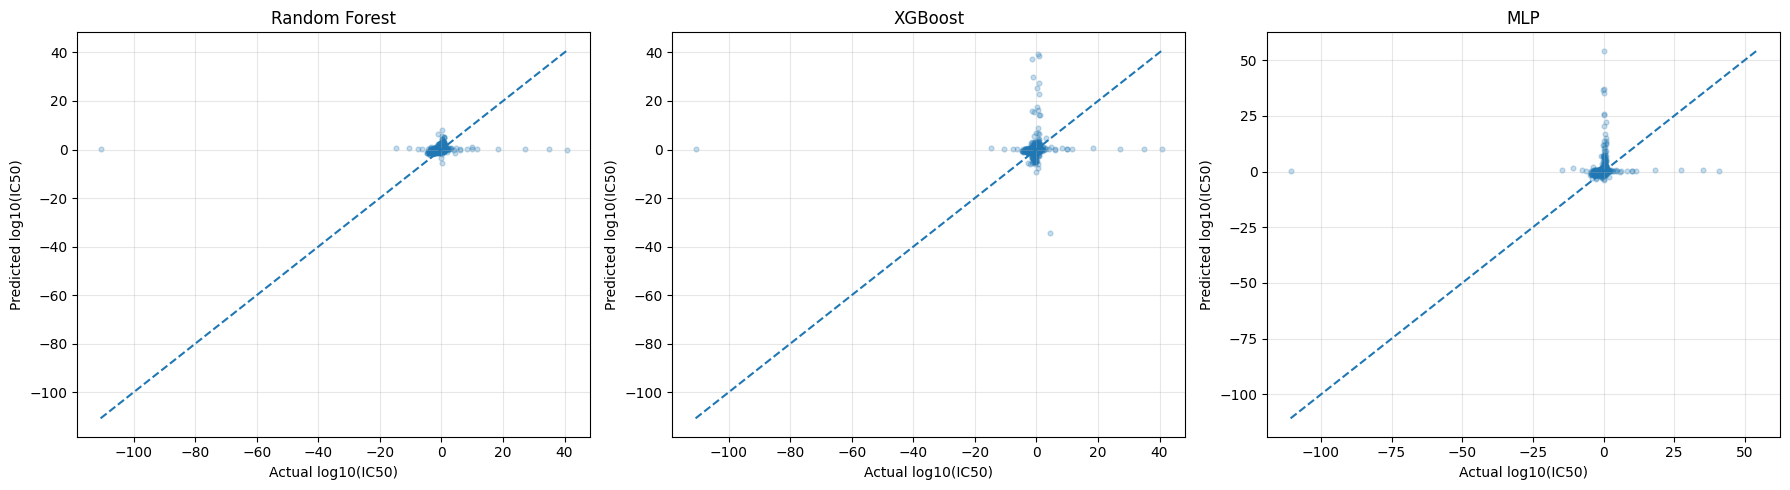

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Random Forest", rf_predictions),
    ("XGBoost", xgb_predictions),
    ("MLP", mlp_predictions)
]

for ax, (name, predictions) in zip(axes, models):
    ax.scatter(
        y_test,
        predictions,
        alpha=0.25,
        s=12
    )

    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    ax.set_title(name)
    ax.set_xlabel("Actual log10(IC50)")
    ax.set_ylabel("Predicted log10(IC50)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

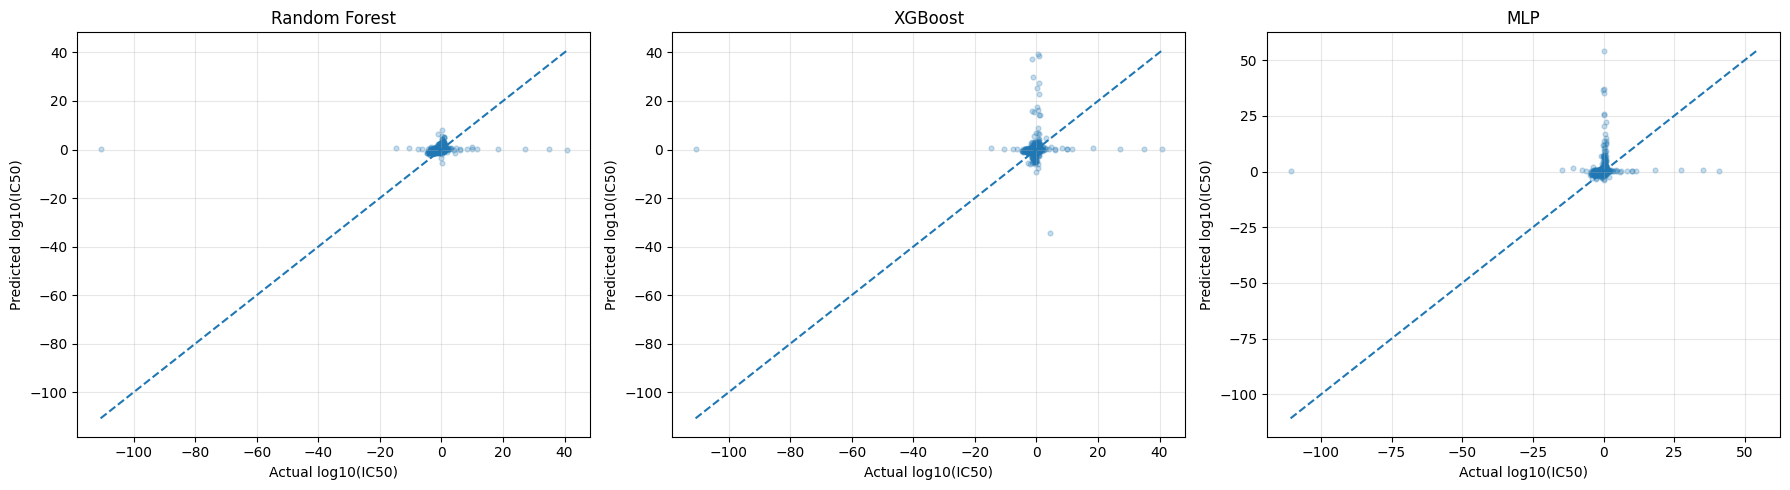

Figure saved:
..\results\figures\phase4_baseline_actual_vs_predicted.png


In [31]:
figure_path = results_dir / "figures" / "phase4_baseline_actual_vs_predicted.png"

plt.figure(figsize=(1, 1))
plt.close()

# Recreate and save the full-range figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, predictions) in zip(axes, models):
    ax.scatter(
        y_test,
        predictions,
        alpha=0.25,
        s=12
    )

    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    ax.set_title(name)
    ax.set_xlabel("Actual log10(IC50)")
    ax.set_ylabel("Predicted log10(IC50)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:")
print(figure_path)

## 26. Zoomed Baseline Prediction Analysis

A second visualization is created for the main response range from -3 to +3 in log10(IC50).

This provides a clearer view of prediction behavior around the majority of observations while keeping the extreme-tail analysis separate.

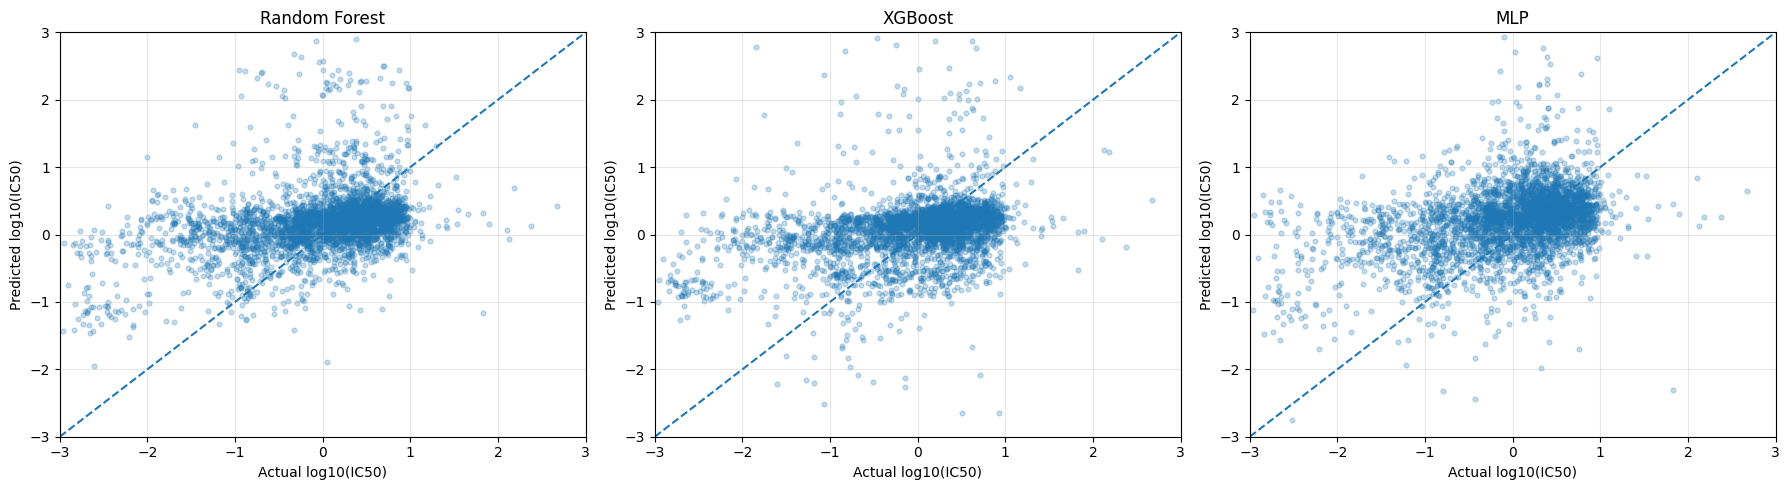

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Random Forest", rf_predictions),
    ("XGBoost", xgb_predictions),
    ("MLP", mlp_predictions)
]

for ax, (name, predictions) in zip(axes, models):

    # Keep observations where actual and predicted values are within the zoom range
    mask = (
        (y_test >= -3) & (y_test <= 3) &
        (predictions >= -3) & (predictions <= 3)
    )

    ax.scatter(
        y_test[mask],
        predictions[mask],
        alpha=0.25,
        s=12
    )

    ax.plot(
        [-3, 3],
        [-3, 3],
        linestyle="--"
    )

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

    ax.set_title(name)
    ax.set_xlabel("Actual log10(IC50)")
    ax.set_ylabel("Predicted log10(IC50)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

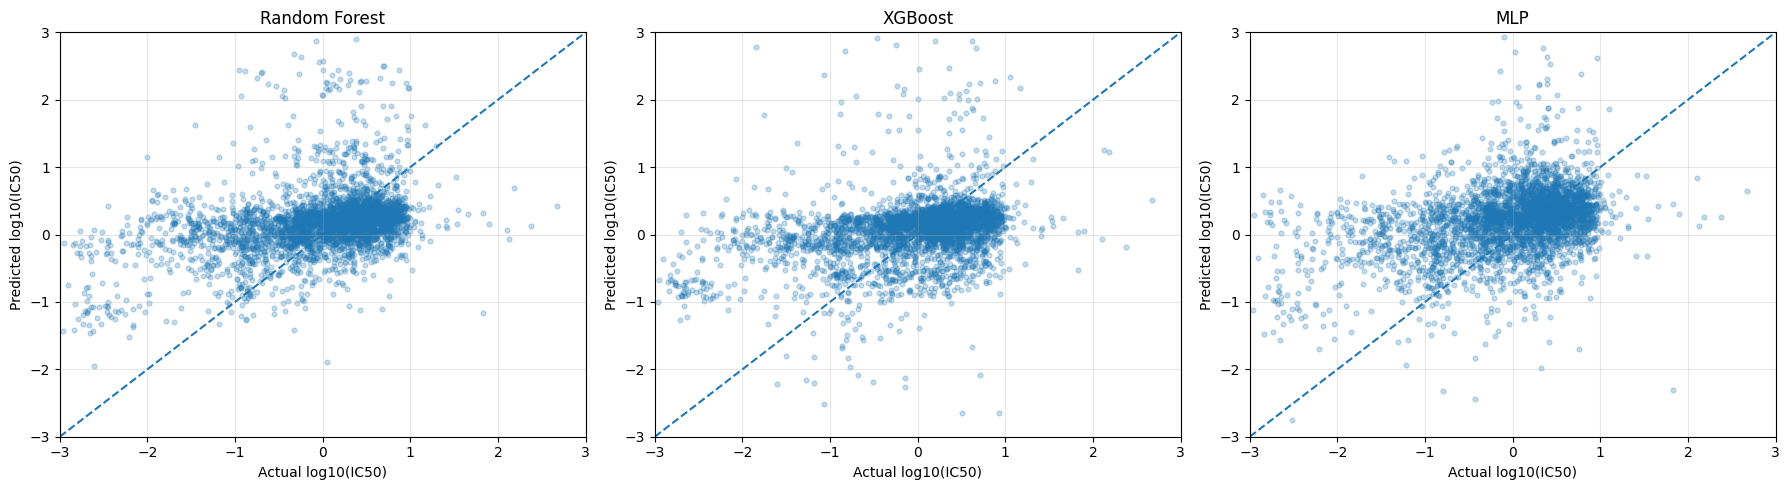

Zoomed figure saved:
..\results\figures\phase4_baseline_actual_vs_predicted_zoomed.png


In [33]:
zoom_figure_path = (
    results_dir / "figures" /
    "phase4_baseline_actual_vs_predicted_zoomed.png"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, predictions) in zip(axes, models):

    mask = (
        (y_test >= -3) & (y_test <= 3) &
        (predictions >= -3) & (predictions <= 3)
    )

    ax.scatter(
        y_test[mask],
        predictions[mask],
        alpha=0.25,
        s=12
    )

    ax.plot(
        [-3, 3],
        [-3, 3],
        linestyle="--"
    )

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(name)
    ax.set_xlabel("Actual log10(IC50)")
    ax.set_ylabel("Predicted log10(IC50)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    zoom_figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Zoomed figure saved:")
print(zoom_figure_path)

## 27. Phase 4 Summary

The baseline machine-learning models established a reference point for cancer drug-response prediction using the fixed cold-drug split.

Three models were evaluated:

- Random Forest
- XGBoost
- MLP

The models showed limited overall predictive performance, with substantial prediction errors in the extreme response ranges.

Response-range analysis showed that prediction errors increased markedly for extreme negative and positive log10(IC50) values. However, the extreme observations were relatively sparse and were previously found to be associated with poorer dose-response curve-fit quality in the PRISM data.

Therefore, the results motivate investigation of the heterogeneous GraphTCDR architecture and, subsequently, a tail-aware learning strategy rather than simply removing the extreme observations.

All baseline metrics, range-wise errors, and prediction visualizations have been saved in the project results directory.

────────────────────────────────
PHASE 4 — Additional Baselines
────────────────────────────────

CNN
DeepTTA
DeepCDR
NerD
GraphDRP

### 28. CNN Baseline

The Convolutional Neural Network (CNN) baseline is added to provide a neural architecture comparison with the MLP.

The CNN will use the same fixed cold-drug training and test split and the same log10(IC50) prediction target.

### 29. Prepare Input for the CNN

The CNN receives the same 2,088-dimensional feature representation used by the other baseline models.

The feature vector is reshaped into a single-channel one-dimensional sequence so that 1D convolutional layers can learn local patterns in the combined molecular and cell-line representation.

The training and testing data remain unchanged.

In [34]:
# Reshape the existing baseline features for 1D CNN input
X_train_cnn = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(1)

X_test_cnn = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(1)

print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: torch.Size([14235, 1, 2088])
CNN testing shape: torch.Size([3802, 1, 2088])


### 30. Define the CNN Architecture

A 1D CNN is used to learn local patterns from the combined drug and cell-line feature representation.

Architecture:

Input (1 × 2088)
↓
Conv1D
↓
ReLU
↓
Max Pooling
↓
Conv1D
↓
ReLU
↓
Max Pooling
↓
Fully Connected Layers
↓
Predicted log10(IC50)

In [35]:
class CNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 522, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        return self.regressor(x)


cnn_model = CNNRegressor().to(device)

print(cnn_model)

CNNRegressor(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=33408, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


### 31. Train the CNN

The CNN is trained using the same training samples and log10(IC50) target as the previous baseline models.

The Adam optimizer and mean squared error loss are used.

In [36]:
cnn_dataset = TensorDataset(
    X_train_cnn,
    y_train_tensor
)

cnn_loader = DataLoader(
    cnn_dataset,
    batch_size=128,
    shuffle=True
)

cnn_criterion = nn.MSELoss()

cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

CNN_EPOCHS = 50

print("Training CNN...")

for epoch in range(CNN_EPOCHS):
    cnn_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in cnn_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        cnn_optimizer.zero_grad()

        predictions = cnn_model(X_batch)

        loss = cnn_criterion(predictions, y_batch)

        loss.backward()
        cnn_optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(cnn_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/{CNN_EPOCHS} - "
            f"Loss: {epoch_loss:.4f}"
        )

Training CNN...
Epoch 10/50 - Loss: 9.1479
Epoch 20/50 - Loss: 2.6164
Epoch 30/50 - Loss: 1.6899
Epoch 40/50 - Loss: 2.8751
Epoch 50/50 - Loss: 1.1986
